## Generate business charts with Gemma 3 12B
This demo shows you how to use specialized Low-Rank Adaptation (LoRA) adapters to transform JSON data into valid SVG charts. You will learn how to use a 12B parameter model to perform high-precision coordinate arithmetic locally.

### Before you begin
1. *Get access* to Gemma 3 on Hugging Face.
2. *Configure your environment* with at least 16GB of unified memory (for Mac) or a T4 GPU (for Colab).
3. Review the [Gemma 3 license agreement](https://ai.google.dev/gemma/terms)

SVG Chart Generation with Gemma 3 12B and LoRA
Keywords: Gemma 3, LoRA, SVG, Data Visualization, MLX, Apple Silicon

This notebook demonstrates how to use specialized LoRA adapters to transform structured
JSON data into production-ready SVG charts.

### Key features:
- Local Inference: Optimized for Apple Silicon using the MLX framework.
- Specialized Adapters: 12 per-type LoRA adapters for Bar, Line, Waterfall, and more.
- Hybrid Architecture: Python owns geometry (deterministic); adapter owns layout and styling.
- 4-Stage Validation: Extraction -> XML Parse -> Content Rules -> Coordinate Repair with repair log.

### Architecture note - why Python owns geometry:
Transformer models predict the next token from learned statistical patterns.
Coordinate arithmetic (trig arc paths, dual-axis normalisation, cumulative running totals)
is deterministic computation, not pattern matching. The adapters learn SVG structure,
element ordering, and color conventions, but memorise example coordinates rather than
compute new ones from data.

Solution: Python pre-computes all geometry before the prompt is sent.
The adapter assembles the SVG from the pre-computed coordinates.
This produces reliable, data-accurate charts at inference time.

## 1. Setup
Install the necessary libraries. This notebook is designed for local inference on Apple Silicon (MLX) and can be adapted for CUDA-enabled environments (Colab) using transformers.

In [10]:
import platform
import os

# Install core dependencies based on hardware
if platform.processor() == 'arm' and platform.system() == 'Darwin':
    %pip install -q mlx-lm
    BACKEND = "mlx"
else:
    %pip install -q transformers peft torch accelerate
    BACKEND = "transformers"

# Standard utilities for SVG processing
import re
import xml.etree.ElementTree as ET
from IPython.display import SVG, display

Note: you may need to restart the kernel to use updated packages.


## 2. Load the Model and Adapters
You can choose from 12 specialized chart types. Each type has a dedicated LoRA adapter trained to handle its specific geometric requirements. Check out the [svg-chart-lora repository](https://huggingface.co/John-Williams-ATL/svg-chart-lora) for more details.

In [2]:
# Since Gemma 3 is a gated model:
# from huggingface_hub import notebook_login
# notebook_login()

In [52]:
# Force MLX backend for the M4 Mac
BACKEND = "mlx" 

# List of available chart types in the svg-chart-lora repository
available_types = [
    "bar", "line", "area", "pie", "donut", "funnel", 
    "scatter", "bubble", "grouped_bar", "stacked_bar", 
    "waterfall", "horizontal_bar"
]

# Set your desired chart type here
CHART_TYPE = "stacked_bar" 

if CHART_TYPE not in available_types:
    raise ValueError(f"Invalid chart type. Please choose from: {available_types}")

model_id = "mlx-community/gemma-3-12b-it-4bit"
# This points to your confirmed local folder
adapter_id = f"svg-chart-lora/adapters_{CHART_TYPE}"
# adapter_id = f"John-Williams-ATL/svg-chart-lora/{CHART_TYPE}_final"

print(f"Loading {model_id} with specialized adapter: {CHART_TYPE}...")
print(f"Loading {model_id} (4-bit)...")

# Load model and adapter using MLX (for Apple Silicon)
# Note: For CUDA, use PeftModel.from_pretrained() from the transformers library
if BACKEND == "mlx":
    from mlx_lm import load, generate
    # lazy=True ensures we don't spike memory during the initial handshake
    model, tokenizer = load(model_id, adapter_path=adapter_id, lazy=True)
    print("✅ Model loaded successfully! Your M4 is now optimized.")
else:
    from transformers import AutoModelForCausalLM, AutoTokenizer
    from peft import PeftModel
    # Standard Transformers loading logic
    base_model = AutoModelForCausalLM.from_pretrained(model_id, device_map="auto")
    model = PeftModel.from_pretrained(base_model, adapter_id)
    tokenizer = AutoTokenizer.from_pretrained(model_id)
    # Define a simple generate wrapper for transformers to match mlx_lm's signature
    def generate(model, tokenizer, prompt, max_tokens, temp):
        inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
        outputs = model.generate(**inputs, max_new_tokens=max_tokens, temperature=temp)
        return tokenizer.decode(outputs[0], skip_special_tokens=True)

Loading mlx-community/gemma-3-12b-it-4bit with specialized adapter: stacked_bar...
Loading mlx-community/gemma-3-12b-it-4bit (4-bit)...


Fetching 13 files: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████| 13/13 [00:00<00:00, 33951.40it/s]


✅ Model loaded successfully! Your M4 is now optimized.


## 3. Geometry helpers and validation pipeline

### 3a. Geometry pre-computation
Functions below pre-compute all coordinates requiring deterministic calculation.
Each accepts an optional palette= parameter for brand color overrides.

| Strategy | Types |
|----------|-------|
| Pre-compute required (trig/dual-axis/cumulative) | donut, pie, scatter, bubble, waterfall |
| Pre-compute for reliability | area, line, stacked_bar |
| Model handles well from data prompt | bar, grouped_bar, horizontal_bar, funnel |

### 3b. Validation pipeline
- Gate 0: Guard against None/empty output
- Gate 1: Strip think-blocks and markdown fences
- Gate 2: Full XML parse
- Gate 3: Verify viewBox dimensions
- Gate 4/4b/4c: Coordinate repair with per-gate repair log

Validator also injects XML declaration, xmlns, and font-family on the SVG root
for correct rendering in browsers and downstream SVG consumers.

In [53]:
import math

# DEFAULT_PALETTE - pass a custom dict to any geometry function to override brand colors.
# Upstream processes (slide theme, brand config, prior prompt output) can supply
# palette at generation time - the geometry layer consumes whatever it receives.
DEFAULT_PALETTE = {
    "background": "#f5f5f5",
    "text":       "#333333",
    "font":       "sans-serif",   # applied via font-family on SVG root by validator
    "primary":    "#4a90d9",      # start/total bars, single-series charts
    "positive":   "#27ae60",      # positive delta bars (waterfall)
    "negative":   "#e67e22",      # negative delta bars (waterfall)
    "series":     ["#4a90d9", "#e67e22", "#27ae60", "#8e44ad"]  # multi-series
}

def compute_donut_arcs(data, cx=250, cy=160, r_outer=110, r_inner=55, palette=None):
    # palette: optional color override (see DEFAULT_PALETTE)
    # Returns label_x/label_y at arc midpoint (72% of r_outer) for label placement.
    """
    Pre-computes SVG ring-arc paths for a donut chart.
    Pass the output into user_turn so the model assembles SVG, not geometry.
    """
    total = sum(d["value"] for d in data)
    angle = -math.pi / 2  # start at top (12 o'clock)
    arcs = []
    for d in data:
        sweep = (d["value"] / total) * 2 * math.pi
        x1o = cx + r_outer * math.cos(angle)
        y1o = cy + r_outer * math.sin(angle)
        x1i = cx + r_inner * math.cos(angle)
        y1i = cy + r_inner * math.sin(angle)
        angle += sweep
        x2o = cx + r_outer * math.cos(angle)
        y2o = cy + r_outer * math.sin(angle)
        x2i = cx + r_inner * math.cos(angle)
        y2i = cy + r_inner * math.sin(angle)
        laf = 1 if sweep > math.pi else 0
        mid_angle = angle - sweep / 2
        label_x = cx + (r_outer * 0.72) * math.cos(mid_angle)
        label_y = cy + (r_outer * 0.72) * math.sin(mid_angle)
        arcs.append({
            "label": d["label"],
            "value": d["value"],
            "path":    f"M{x1o:.1f},{y1o:.1f} A{r_outer},{r_outer} 0 {laf},1 {x2o:.1f},{y2o:.1f} L{x2i:.1f},{y2i:.1f} A{r_inner},{r_inner} 0 {laf},0 {x1i:.1f},{y1i:.1f} Z",
            "label_x": round(label_x, 1),
            "label_y": round(label_y, 1)
        })
    return arcs

def compute_pie_slices(data, cx=250, cy=160, r=110, palette=None):
    # palette: optional color override (see DEFAULT_PALETTE)
    """
    Pre-computes SVG wedge paths for a pie chart.
    """
    total = sum(d["value"] for d in data)
    angle = -math.pi / 2  # start at 12 o'clock
    slices = []
    for d in data:
        sweep = (d["value"] / total) * 2 * math.pi
        x1 = cx + r * math.cos(angle)
        y1 = cy + r * math.sin(angle)
        angle += sweep
        x2 = cx + r * math.cos(angle)
        y2 = cy + r * math.sin(angle)
        laf = 1 if sweep > math.pi else 0
        # Label at arc midpoint
        mid_angle = angle - sweep / 2
        label_x = cx + (r * 0.65) * math.cos(mid_angle)
        label_y = cy + (r * 0.65) * math.sin(mid_angle)
        slices.append({
            "label": d["label"],
            "value": d["value"],
            "path": f"M{cx},{cy} L{x1:.1f},{y1:.1f} A{r},{r} 0 {laf},1 {x2:.1f},{y2:.1f} Z",
            "label_x": round(label_x, 1),
            "label_y": round(label_y, 1)
        })
    return slices

def compute_scatter_points(data, x_key="x", y_key="y",
                            plot_x0=50, plot_x1=480,
                            plot_y0=30, plot_y1=270,
                            padding=30):
    x_vals = [d[x_key] for d in data]
    y_vals = [d[y_key] for d in data]
    x_min, x_max = min(x_vals), max(x_vals)
    y_min, y_max = min(y_vals), max(y_vals)
    x_range = x_max - x_min or 1
    y_range = y_max - y_min or 1

    # Inset so extreme points don't sit on axis lines
    x0 = plot_x0 + padding
    x1 = plot_x1 - padding
    y0 = plot_y0 + padding
    y1 = plot_y1 - padding

    points = []
    for d in data:
        cx = x0 + (d[x_key] - x_min) / x_range * (x1 - x0)
        cy = y1 - (d[y_key] - y_min) / y_range * (y1 - y0)
        points.append({
            "label": d.get("label", ""),
            "x_val": d[x_key],
            "y_val": d[y_key],
            "cx": round(cx, 1),
            "cy": round(cy, 1)
        })
    return points, (x_min, x_max), (y_min, y_max)

def compute_bubble_points(data, x_key="x", y_key="y", size_key="size",
                           plot_x0=50, plot_x1=480,
                           plot_y0=30, plot_y1=270,
                           r_min=10, r_max=50):
    x_vals = [d[x_key] for d in data]
    y_vals = [d[y_key] for d in data]
    s_vals = [d[size_key] for d in data]
    x_min, x_max = min(x_vals), max(x_vals)
    y_min, y_max = min(y_vals), max(y_vals)
    s_min, s_max = min(s_vals), max(s_vals)
    x_range = x_max - x_min or 1
    y_range = y_max - y_min or 1
    s_range = s_max - s_min or 1

    # Inset plot area by max radius so bubbles don't clip the axes
    pad = r_max
    x0 = plot_x0 + pad
    x1 = plot_x1 - pad
    y0 = plot_y0 + pad
    y1 = plot_y1 - pad

    points = []
    for d in data:
        cx = x0 + (d[x_key] - x_min) / x_range * (x1 - x0)
        cy = y1 - (d[y_key] - y_min) / y_range * (y1 - y0)
        r  = r_min + (d[size_key] - s_min) / s_range * (r_max - r_min)
        label = d.get("label", "")
        est_text_width = len(label) * 6
        label_position = "inside" if est_text_width < r * 1.5 else "above"
        label_y = round(cy + 4, 1) if label_position == "inside" else round(cy - r - 5, 1)
        points.append({
            "label":          label,
            "x_val":          d[x_key],
            "y_val":          d[y_key],
            "size_val":       d[size_key],
            "cx":             round(cx, 1),
            "cy":             round(cy, 1),
            "r":              round(r, 1),
            "label_position": label_position,
            "label_y":        label_y
        })
    return points, (x_min, x_max), (y_min, y_max)

def compute_waterfall_bars(data, plot_x0=50, plot_x1=480, baseline=270, max_height=240):
    n = len(data)
    slot = (plot_x1 - plot_x0) / n
    bar_width = slot * 0.7
    max_val = max(abs(d["value"]) for d in data)
    scale = max_height / max_val

    bars = []
    running = 0
    for i, d in enumerate(data):
        bar_x = plot_x0 + i * slot + slot * 0.15
        value = d["value"]
        is_total = d.get("isTotal", False)
        is_first = i == 0

        if is_first or is_total:
            bar_height = abs(value) * scale
            bar_y = baseline - bar_height
            color = "#4a90d9"
            if not is_total:
                running += value
        elif value >= 0:
            bar_height = value * scale
            bar_y = baseline - running * scale - bar_height
            color = "#27ae60"
            running += value
        else:
            running_before = running
            running += value
            bar_height = abs(value) * scale
            bar_y = baseline - running_before * scale
            color = "#e67e22"

        label_inside = bar_height > 30  # True: label fits inside bar; False: float above
        label_x = round(bar_x + bar_width / 2, 1)
        label_y = round(bar_y + bar_height / 2 + 4, 1) if label_inside else round(bar_y - 5, 1)
        bars.append({
            "label":        d["label"],
            "value":        value,
            "bar_x":        round(bar_x, 1),
            "bar_y":        round(bar_y, 1),
            "bar_width":    round(bar_width, 1),
            "bar_height":   round(bar_height, 1),
            "color":        color,
            "label_x":      label_x,
            "label_y":      label_y,
            "label_inside": label_inside
        })
    return bars

def compute_line_points(data, value_key="value",
                         plot_x0=50, plot_x1=480,
                         plot_y0=30, plot_y1=270):
    n = len(data)
    vals = [d[value_key] for d in data]
    y_min, y_max = 0, max(vals)  # baseline at 0
    x_range = plot_x1 - plot_x0
    y_range = plot_y1 - plot_y0

    points = []
    for i, d in enumerate(data):
        cx = plot_x0 + (i / (n - 1)) * x_range
        cy = plot_y1 - (d[value_key] / y_max) * y_range
        points.append({
            "label": d.get("label", ""),
            "value": d[value_key],
            "cx": round(cx, 1),
            "cy":      round(cy, 1),
            "label_y": round(cy - 8, 1)   # 8px above point, clear of line stroke
        })
    y_ticks = [
        {"val": round(y_max * i / 2), "cy": round(plot_y1 - (i / 2) * y_range)}
        for i in range(3)
    ]
    return points, y_max, y_ticks


def compute_area_points(data, value_key="value",
                         plot_x0=50, plot_x1=480,
                         plot_y0=30, plot_y1=270):
    n = len(data)
    vals = [d[value_key] for d in data]
    y_max = max(vals)
    x_range = plot_x1 - plot_x0
    y_range = plot_y1 - plot_y0

    points = []
    for i, d in enumerate(data):
        cx = plot_x0 + (i / (n - 1)) * x_range
        cy = plot_y1 - (d[value_key] / y_max) * y_range
        points.append({
            "label": d.get("label", ""),
            "value": d[value_key],
            "cx": round(cx, 1),
            "cy": round(cy, 1)
        })

    # Area path: start at baseline-left, trace points, close at baseline-right
    first = points[0]
    last = points[-1]
    path_points = " L ".join(f"{p['cx']} {p['cy']}" for p in points)
    area_path = f"M {first['cx']} {plot_y1} L {path_points} L {last['cx']} {plot_y1} Z"

    # Future: smooth=True option using Catmull-Rom to cubic Bezier conversion
    return points, area_path, y_max


def compute_stacked_bars(data, plot_x0=50, plot_x1=480, baseline=270, max_height=240):
    groups = data
    n_groups = len(groups)
    n_series = len(groups[0]["series"])
    slot = (plot_x1 - plot_x0) / n_groups
    bar_width = slot * 0.6

    # Find max total for scaling
    totals = [sum(s["value"] for s in g["series"]) for g in groups]
    max_total = max(totals)
    scale = max_height / max_total

    bars = []
    for i, group in enumerate(groups):
        bar_x = plot_x0 + i * slot + slot * 0.2
        current_y = baseline
        segments = []
        for j, series in enumerate(group["series"]):
            seg_height = round(series["value"] * scale, 1)
            current_y -= seg_height
            segments.append({
                "label": series["label"],
                "value": series["value"],
                "x": round(bar_x, 1),
                "y": round(current_y, 1),
                "width": round(bar_width, 1),
                "height": seg_height,
                "color": ["#4a90d9", "#e67e22", "#27ae60", "#8e44ad"][j % 4]
            })
        bars.append({
            "group": group["group"],
            "label_x": round(bar_x + bar_width / 2, 1),
            "total": sum(s["value"] for s in group["series"]),
            "segments": segments
        })
    return bars

def compute_horizontal_bars(data, value_key="value",
                             plot_x0=50, plot_x1=480,
                             plot_y0=40, plot_y1=260,
                             gap_ratio=0.3):
    n = len(data)
    max_val = max(d[value_key] for d in data)
    usable_y = plot_y1 - plot_y0
    row_height = usable_y / n
    bar_height = round(row_height * (1 - gap_ratio), 1)
    gap = row_height * gap_ratio

    bars = []
    for i, d in enumerate(data):
        bar_y = round(plot_y0 + i * row_height + gap / 2, 1)
        bar_w = round((d[value_key] / max_val) * (plot_x1 - plot_x0), 1)
        # Center of bar for the name label (white text inside bar)
        name_label_x = round(plot_x0 + bar_w / 2, 1)          
        name_label_y = round(bar_y + bar_height / 2, 1)        
        # Value label just past bar end
        value_label_x = round(plot_x0 + bar_w + 5, 1)         
        bars.append({
            "label":          d.get("label", ""),
            "value":          d[value_key],
            "bar_x":          plot_x0,
            "bar_y":          bar_y,
            "bar_w":          bar_w,
            "bar_h":          bar_height,
            "name_label_x":   name_label_x,   
            "name_label_y":   name_label_y,
            "value_label_x":  value_label_x,
        })
    return bars

def compute_funnel_bars(data, value_key="value",
                         cx=250, top_y=40, bar_height=44, gap=6,
                         max_width=400):
    max_val = max(d[value_key] for d in data)
    bars = []
    for i, d in enumerate(data):
        w = round((d[value_key] / max_val) * max_width, 1)
        x = round(cx - w / 2, 1)
        y = top_y + i * (bar_height + gap)
        label_y = round(y + bar_height / 2 + 4, 1)
        bars.append({
            "label":   d.get("label", ""),
            "value":   d[value_key],
            "x":       x,
            "y":       y,
            "width":   w,
            "height":  bar_height,
            "label_y": label_y
        })
    return bars

In [54]:
import re
import xml.etree.ElementTree as ET

class GemmaChartValidator:
    """
    Four-stage SVG validation and repair pipeline.
    Repairs logged per-gate so callers can distinguish cosmetic from geometry fixes.
    Also injects XML declaration, xmlns, and font-family on the SVG root.
    """
    CANVAS_WIDTH = 500
    CANVAS_HEIGHT = 300

    @classmethod
    def validate_and_repair(cls, raw_output, font_family="sans-serif"):
        # GATE 0: Guard against empty/None generation
        if not raw_output:
            return None, "Gate 0: Model returned no output (check prompt tokens)."

        # GATE 1: Extraction & Think-block stripping
        clean_text = re.sub(r"<think>.*?</think>", "", raw_output, flags=re.DOTALL)
        clean_text = re.sub(r"```svg|```", "", clean_text).strip()
        if not clean_text.startswith("<svg"):
            return None, "Gate 1: Missing SVG root."

        try:
            # GATE 2: XML Parsing
            root = ET.fromstring(clean_text)

            # GATE 3: Content Rules (viewBox & Geometry)
            if root.get("viewBox") != f"0 0 {cls.CANVAS_WIDTH} {cls.CANVAS_HEIGHT}":
                return None, "Gate 3: Invalid ViewBox."

            if not root.get("xmlns"):
                root.set("xmlns", "http://www.w3.org/2000/svg")
            if not root.get("font-family"):
                root.set("font-family", font_family)

            ET.register_namespace('', "http://www.w3.org/2000/svg")
            ns = {"svg": "http://www.w3.org/2000/svg"}
            repaired = False
            repair_log = []

            # GATE 4: Text label overflow repair
            texts = root.findall(".//svg:text", ns)
            if not texts:
                texts = root.findall(".//text")
            for text in texts:
                x = float(text.get("x", 0))
                if x > (cls.CANVAS_WIDTH - 10):
                    text.set("x", str(cls.CANVAS_WIDTH - 15))
                    repaired = True
                    repair_log.append(f"Gate 4: text x clamped from {x}")

            # GATE 4b: Rect coordinate repair (bars only — skip background rect and legend swatches)
            rects = root.findall(".//svg:rect", ns)
            if not rects:
                rects = root.findall(".//rect")
            for rect in rects:
                try:
                    y = float(rect.get("y", 0))
                    h = float(rect.get("height", 0))
                    w = float(rect.get("width", 999))
                    if y == 0 and h >= cls.CANVAS_HEIGHT:
                        continue
                    if w <= 15 and h <= 15: #Skip legend swatches
                        continue
                    if y + h > 270:
                        rect.set("height", str(270 - y))
                        repaired = True
                        repair_log.append(f"Gate 4b: rect height clamped (y={y}, h={h} → {270 - y})")
                except ValueError:
                    pass

            # GATE 4c: Axis line stroke repair
            lines = root.findall(".//svg:line", ns)
            if not lines:
                lines = root.findall(".//line")
            for line in lines:
                if not line.get("stroke"):
                    line.set("stroke", "#333333")
                    line.set("stroke-width", "1")
                    repaired = True
                    repair_log.append("Gate 4c: missing stroke added to line")

            final_svg = '<?xml version="1.0" encoding="UTF-8"?>\n' + ET.tostring(root, encoding="unicode")
            status = "Success"
            if repaired:
                status += f" (Repaired: {'; '.join(repair_log)})"
            return final_svg, status

        except Exception as e:
            return None, f"Validation Failed: {str(e)}"

## 4. Generate a Chart

Set `CHART_TYPE` in Cell 7 and re-run it, then run this cell.
The model does not need to be reloaded between chart types.

| Strategy | Types |
|----------|-------|
| Pre-compute required | donut, pie, scatter, bubble, waterfall |
| Pre-compute for reliability | area, line, stacked_bar |
| Model handles well | bar, grouped_bar, horizontal_bar, funnel |

🚀 M4 is generating the stacked_bar chart using the trained schema...
<svg viewBox="0 0 500 300" width="500" height="300"><rect width="500" height="300" fill="#f5f5f5"/><text x="250" y="22" text-anchor="middle" font-size="14" fill="#333333">Revenue by Product Line ($M)</text><line x1="50" y1="270" x2="480" y2="270" stroke="#333333" stroke-width="1"/><line x1="50" y1="30" x2="50" y2="270" stroke="#333333" stroke-width="1"/><rect x="78.7" y="182.7" width="86.0" height="87.3" fill="#4a90d9"/><rect x="78.7" y="131.8" width="86.0" height="50.9" fill="#e67e22"/><rect x="78.7" y="95.4" width="86.0" height="36.4" fill="#27ae60"/><text x="121.7" y="285" text-anchor="middle" font-size="11" fill="#333333">Q1</text><text x="121.7" y="177" text-anchor="middle" font-size="10" fill="#333333">120</text><rect x="222.0" y="160.9" width="86.0" height="109.1" fill="#4a90d9"/><rect x="222.0" y="102.7" width="86.0" height="58.2" fill="#e67e22"/><rect x="222.0" y="62.0" width="86.0" height="40.7" fill="#27ae6

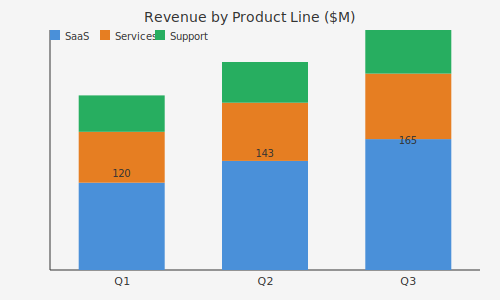

In [55]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(), "svg-chart-lora", "scripts"))
from per_type_system_prompts import SYSTEM_PROMPTS

# Sample data per chart type
sample_data = {
    "bar": {
        "heading": "Quarterly Revenue ($M)",
        "data": [{"label": "Q1", "value": 120}, {"label": "Q2", "value": 185}, {"label": "Q3", "value": 210}]
    },
    "donut": {
        "heading": "Revenue by Region",
        "data": [{"label": "North", "value": 45}, {"label": "South", "value": 35}, {"label": "West", "value": 20}]
    },
    "pie": {
        "heading": "Market Share (%)",
        "data": [{"label": "Us", "value": 45}, {"label": "Competitor A", "value": 30}, {"label": "Competitor B", "value": 25}]
    },
    "line": {
        "heading": "Monthly Recurring Revenue ($K)",
        "data": [{"label": "Jan", "value": 80}, {"label": "Feb", "value": 95}, {"label": "Mar", "value": 110}, {"label": "Apr", "value": 130}, {"label": "May", "value": 155}]
    },
    "area": {
        "heading": "Website Sessions (K)",
        "data": [{"label": "Jan", "value": 40}, {"label": "Feb", "value": 55}, {"label": "Mar", "value": 70}, {"label": "Apr", "value": 65}, {"label": "May", "value": 90}]
    },
    "funnel": {
        "heading": "Sales Pipeline",
        "data": [{"label": "Leads", "value": 1000}, {"label": "Qualified", "value": 600}, {"label": "Proposal", "value": 300}, {"label": "Closed", "value": 120}]
    },
    "scatter": {
        "heading": "Deal Size vs Close Rate (%)",
        "data": [{"x": 10, "y": 80, "label": "SMB"}, {"x": 50, "y": 55, "label": "Mid"}, {"x": 120, "y": 40, "label": "Corp"}, {"x": 300, "y": 25, "label": "Ent"}, {"x": 500, "y": 15, "label": "Strat"}]
    },
    "bubble": {
        "heading": "Segment: Revenue vs Growth vs Headcount",
        "data": [{"x": 100, "y": 30, "size": 40, "label": "SMB"}, {"x": 250, "y": 55, "size": 80, "label": "Mid"}, {"x": 400, "y": 20, "size": 120, "label": "Ent"}]
    },
    "grouped_bar": {
        "heading": "Headcount by Team (Q1-Q3)",
        "data": [
            {"group": "Q1", "series": [{"label": "Eng", "value": 80}, {"label": "Sales", "value": 50}, {"label": "Ops", "value": 30}]},
            {"group": "Q2", "series": [{"label": "Eng", "value": 100}, {"label": "Sales", "value": 60}, {"label": "Ops", "value": 40}]},
            {"group": "Q3", "series": [{"label": "Eng", "value": 120}, {"label": "Sales", "value": 70}, {"label": "Ops", "value": 50}]}
        ]
    },
    "stacked_bar": {
        "heading": "Revenue by Product Line ($M)",
        "data": [
            {"group": "Q1", "series": [{"label": "SaaS", "value": 60}, {"label": "Services", "value": 35}, {"label": "Support", "value": 25}]},
            {"group": "Q2", "series": [{"label": "SaaS", "value": 75}, {"label": "Services", "value": 40}, {"label": "Support", "value": 28}]},
            {"group": "Q3", "series": [{"label": "SaaS", "value": 90}, {"label": "Services", "value": 45}, {"label": "Support", "value": 30}]}
        ]
    },
    "waterfall": {
        "heading": "Net Income Bridge ($M)",
        "data": [
            {"label": "Gross Revenue", "value": 1000},
            {"label": "COGS", "value": -400},
            {"label": "OpEx", "value": -300},
            {"label": "Net Income", "value": 300, "isTotal": True}
        ]
    },
    "horizontal_bar": {
        "heading": "Pipeline by Rep ($K)",
        "data": [{"label": "Alice", "value": 320}, {"label": "Bob", "value": 275}, {"label": "Carol", "value": 410}, {"label": "Dave", "value": 190}, {"label": "Eve", "value": 355}]
    }
}

# Select data based on chart type, fall back to bar
input_content = sample_data.get(CHART_TYPE, sample_data["bar"])
data_points = input_content.get('data', [])
heading = input_content.get('heading', 'Quarterly Report')

# Build the user turn
# Pre-compute geometry for types that require trig
if CHART_TYPE == "donut":
    precomputed_arcs = compute_donut_arcs(data_points)
    arc_instructions = "\n".join(
        f"  Segment '{a['label']}' ({a['value']}): path=\"{a['path']}\", label at x={a['label_x']} y={a['label_y']} text-anchor=middle"
        for a in precomputed_arcs
    )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Pre-computed ring arc paths (use these exactly):
{arc_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "pie":
    precomputed = compute_pie_slices(data_points)
    geo_instructions = "\n".join(
        f"  Slice '{s['label']}' ({s['value']}): path=\"{s['path']}\", label at x={s['label_x']} y={s['label_y']} text-anchor=middle"
        for s in precomputed
    )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Pre-computed wedge paths (use these exactly):
{geo_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "scatter":
    precomputed, x_range, y_range = compute_scatter_points(data_points)
    point_instructions = "\n".join(
        f"  '{p['label']}' (x={p['x_val']}, y={p['y_val']}): cx={p['cx']} cy={p['cy']}"
        for p in precomputed
    )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
X axis range: {x_range[0]} to {x_range[1]}
Y axis range: {y_range[0]} to {y_range[1]}
Pre-computed point positions (use these exactly):
{point_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "bubble":
    precomputed, x_range, y_range = compute_bubble_points(data_points)
    point_instructions = "\n".join(
        f"  '{p['label']}' (x={p['x_val']}, y={p['y_val']}, size={p['size_val']}): cx={p['cx']} cy={p['cy']} r={p['r']} label-position={p['label_position']} label-y={p['label_y']}"
        for p in precomputed
    )
    # Pre-compute 3 axis ticks for each axis
    x_ticks = [
        {"val": round(x_range[0] + i * (x_range[1] - x_range[0]) / 2),
         "cx":  round(100 + i * (430 - 100) / 2)}
        for i in range(3)
    ]
    y_ticks = [
        {"val": round(y_range[0] + i * (y_range[1] - y_range[0]) / 2),
         "cy":  round(220 - i * (220 - 80) / 2)}
        for i in range(3)
    ]
    x_tick_str = ", ".join(f"x={t['cx']} label={t['val']}" for t in x_ticks)
    y_tick_str = ", ".join(f"y={t['cy']} label={t['val']}" for t in y_ticks)

    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
X axis: horizontal line at y=270, spanning x=50 to x=480. Ticks at y=280: {x_tick_str}
Y axis: vertical line at x=50, spanning y=30 to y=270. Ticks at x=40 text-anchor=end: {y_tick_str}
Pre-computed bubbles. label-position=inside: center at cx,label-y. label-position=above: place above at cx,label-y:
{point_instructions}

Return ONLY the SVG code."""
    
elif CHART_TYPE == "waterfall":
    bars = compute_waterfall_bars(data_points)
    bar_instructions = []
    for b in bars:
        inside_note = "(inside bar)" if b["label_inside"] else "(above bar)"
        bar_instructions.append(
            f"  '{b['label']}' ({b['value']}): x={b['bar_x']} y={b['bar_y']} width={b['bar_width']} height={b['bar_height']} fill=\"{b['color']}\"; label at x={b['label_x']} y={b['label_y']} {inside_note}"
        )
    bar_instructions = "\n".join(bar_instructions)
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Baseline: y=270
X axis: horizontal line at y=270, spanning x=50 to x=480
Pre-computed bar positions (use exactly). Place labels at the specified coordinates:
{bar_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "line":
    precomputed, y_max, y_ticks = compute_line_points(data_points)
    path_d = "M " + " L ".join(f"{p['cx']} {p['cy']}" for p in precomputed)
    point_instructions = "\n".join(
        f"  '{p['label']}' ({p['value']}): cx={p['cx']} cy={p['cy']} label-y={p['label_y']}"
        for p in precomputed
    )
    tick_str = ", ".join(f"y={t['cy']} label={t['val']}" for t in y_ticks)
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
X axis: horizontal line at y=270, spanning x=50 to x=480
Y axis: vertical line at x=50, spanning y=30 to y=270
Y axis ticks at x=45 text-anchor=end: {tick_str}
Y axis max: {y_max}
Category labels at y=285 text-anchor=middle
Pre-computed path (use exactly, fill=none): {path_d}
Pre-computed points - circle marker at cx/cy, value label centered at cx label-y (above point):
{point_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "area":
    precomputed, area_path, y_max = compute_area_points(data_points)
    point_instructions = "\n".join(
        f"  '{p['label']}' ({p['value']}): cx={p['cx']} cy={p['cy']}"
        for p in precomputed
    )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
X axis: horizontal line at y=270, spanning x=50 to x=480
Y axis: vertical line at x=50, spanning y=30 to y=270
Y axis max: {y_max}
Pre-computed area path (use exactly, fill-opacity=0.7): {area_path}
Pre-computed points - wrap all category labels (y=285) in a single <g font-size="10" fill="#333333"> element:
{point_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "stacked_bar":
    bars = compute_stacked_bars(data_points)
    bar_instructions = []
    for b in bars:
        bar_instructions.append(f"  Group '{b['group']}' (total={b['total']}, label_x={b['label_x']}):")
        for s in b["segments"]:
            bar_instructions.append(
                f"    '{s['label']}' ({s['value']}): x={s['x']} y={s['y']} width={s['width']} height={s['height']} fill=\"{s['color']}\""
            )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Baseline: y=270
X axis: horizontal line at y=270, spanning x=50 to x=480
Y axis: vertical line at x=50, spanning y=30 to y=270
Pre-computed segments (stack bottom to top, use coordinates exactly):
{chr(10).join(bar_instructions)}

Return ONLY the SVG code."""

elif CHART_TYPE == "horizontal_bar":
    bars = compute_horizontal_bars(data_points)
    bar_instructions = "\n".join(
        f"  '{b['label']}' ({b['value']}): x={b['bar_x']} y={b['bar_y']} "
        f"width={b['bar_w']} height={b['bar_h']} "
        f"name-label: x={b['name_label_x']} y={b['name_label_y']} "
        f"text-anchor=middle fill=white dominant-baseline=central. "
        f"value-label: x={b['value_label_x']} y={b['name_label_y']} fill=#333333"
        for b in bars
    )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Y axis: vertical line at x=50, spanning y=40 to y=260
Pre-computed bars. Category label: x=45 text-anchor=end dominant-baseline=central y=category-label-y. Value label: x=bar_x+bar_width+5:
{bar_instructions}

Return ONLY the SVG code."""

elif CHART_TYPE == "funnel":
    bars = compute_funnel_bars(data_points)
    bar_instructions = "\n".join(
        f"  '{b['label']}' ({b['value']}): x={b['x']} y={b['y']} width={b['width']} height={b['height']} label at x=250 y={b['label_y']}"
        for b in bars
    )
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Pre-computed bars (centered at x=250, use coordinates exactly, label centered in each bar):
{bar_instructions}

Return ONLY the SVG code."""

else:
    user_turn = f"""Chart type: {CHART_TYPE}
Heading: {heading}
Data: {data_points}

Return ONLY the SVG code."""

# Apply Gemma 3 chat template with the correct system prompt
messages = [
    {"role": "system", "content": SYSTEM_PROMPTS[CHART_TYPE]},
    {"role": "user", "content": user_turn}
]

prompt = tokenizer.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True
)

print(f"🚀 M4 is generating the {CHART_TYPE} chart using the trained schema...")

raw_response = generate(
    model,
    tokenizer,
    prompt=prompt,
    max_tokens=1500,
    verbose=True
)

# Validate and display
valid_svg, status = GemmaChartValidator.validate_and_repair(raw_response)
print(f"Validation Status: {status}")

print("\n--- Final SVG (post-validation) ---")
if valid_svg:
    print(valid_svg)
else:
    print("No valid SVG produced.")
print("--- End SVG ---\n")

if valid_svg:
    display(SVG(valid_svg))